In [1]:
import numpy as np
import pymc as pm
import arviz as az

import matplotlib.pyplot as plt
import pandas as pd
import time

from scipy.stats import wishart
from scipy.linalg import solve_triangular

# Set random seed for reproducibility
rng = np.random.default_rng(12345)

"In these experiments the target distribution was a **zero-mean** 250-dimensional multivariate
normal with known precision matrix"

"NUTS was run with
**δ = 0.5 for 2,000 iterations, with the first 1,000 iterations being used as warmup and to adapt ε**." (qualitative testing)

**NUTS’s best performance seems to occur around δ = 0.6, but
does not seem to depend strongly on δ within the range δ ∈ [0.45, 0.65]. δ = 0.6 therefore
seems like a reasonable default value for NUTS.**

"In all experiments the **dual averaging parameters were set to γ = 0.05, t0 = 10, and κ = 0.75**."

"we compute **ESS separately for each dimension and report the minimum ESS across all dimensions**, since we want our samplers to effectively explore all dimensions of the target distribution. For each dimension we compute ESS in terms of the variance of the estimator of that dimension’s mean and second central moment (where the **estimate of the mean used to compute the second central moment is taken from a separate long run of 50,000 iterations of NUTS with δ = 0.5**), reporting whichever statistic has a lower effective sample size. We include the second central moment as well as the mean in order to measure each algorithm’s ability to estimate uncertainty."

"The matrix A was generated from a Wishart distribution with identity scale matrix and 250 degrees of freedom."

In [2]:
D = 250      # number of dimensions
N = 1000     # number of observations
df = 250     # number of degrees of freedom for precision matrix
warmup = 1000
delta = 0.60     # target acceptance rate

'''
# 1) Draw precision from Wishart(df, I)
A = wishart.rvs(df=df, scale=np.eye(D), random_state=rng)  # precision

# 2) Sample theta ~ N(0, A^{-1}) without inverting
L = np.linalg.cholesky(A)          # A = L L^T
Z = rng.standard_normal((N, D))    # iid N(0, I)

# 3) Solve L^T theta^T = z^T  -> theta = (L^T)^{-1} z
Theta = solve_triangular(L.T, Z.T, lower=False).T  # shape (N, D), with 1 column for every variable
'''

# But if we just treat the distribution as our posterior, we can simply draw from it with pyMC

A = wishart.rvs(df=df, scale=np.eye(D), random_state=rng).astype(np.float64)

# Saving precision matrix to file for reproducibility
np.save("PrecisionMatrix.npy", A, allow_pickle=True)

In [3]:
with pm.Model() as model:
    theta = pm.MvNormal("theta", mu=np.zeros(D), tau=A, shape=D)  # tau = precision

    idata = pm.sample(
        draws = N,
        tune = warmup,
        chains = 4,
        target_accept = delta,
        random_seed = 2026,
        progressbar = True,
        nuts_sampler = "pymc"
    )
    
# Checking results

theta_draws = idata.posterior["theta"].values  # shape (chains, draws, D)
theta_flat = theta_draws.reshape(-1, D)

q = np.einsum("ni,ij,nj->n", theta_flat, A, theta_flat)

print("mean q (theory D):", q.mean(), f"({D})")
print("var  q (theory 2D):", q.var(), f"({2*D})")

mean_emp = theta_flat.mean(axis=0)
print("mean abs avg:", np.abs(mean_emp).mean())

cov_emp = np.cov(theta_flat, rowvar=False, bias=True)
cov_theory = np.linalg.inv(A)
rel_err = np.linalg.norm(cov_emp - cov_theory, 'fro') / np.linalg.norm(cov_theory, 'fro')
print("rel cov error:", rel_err)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 235 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


mean q (theory D): 250.13076877923928 (250)
var  q (theory 2D): 522.8773425110643 (500)
mean abs avg: 0.10027946576623505
rel cov error: 0.02313725659234493


/home/mattia/anaconda3/envs/alice/lib/python3.13/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='theta\n0'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n1'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n2'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n3'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n4'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n5'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n6'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='theta\n0', ylabel='theta\n7'>,
        <Axes: xlabel='theta\n1'>, <Axes: xlabel='theta\n2'>,
        <Axes: xlabel='theta\n3'>, <Axes: xlabel='theta\n4'>,
        <Axes: xlabel='t

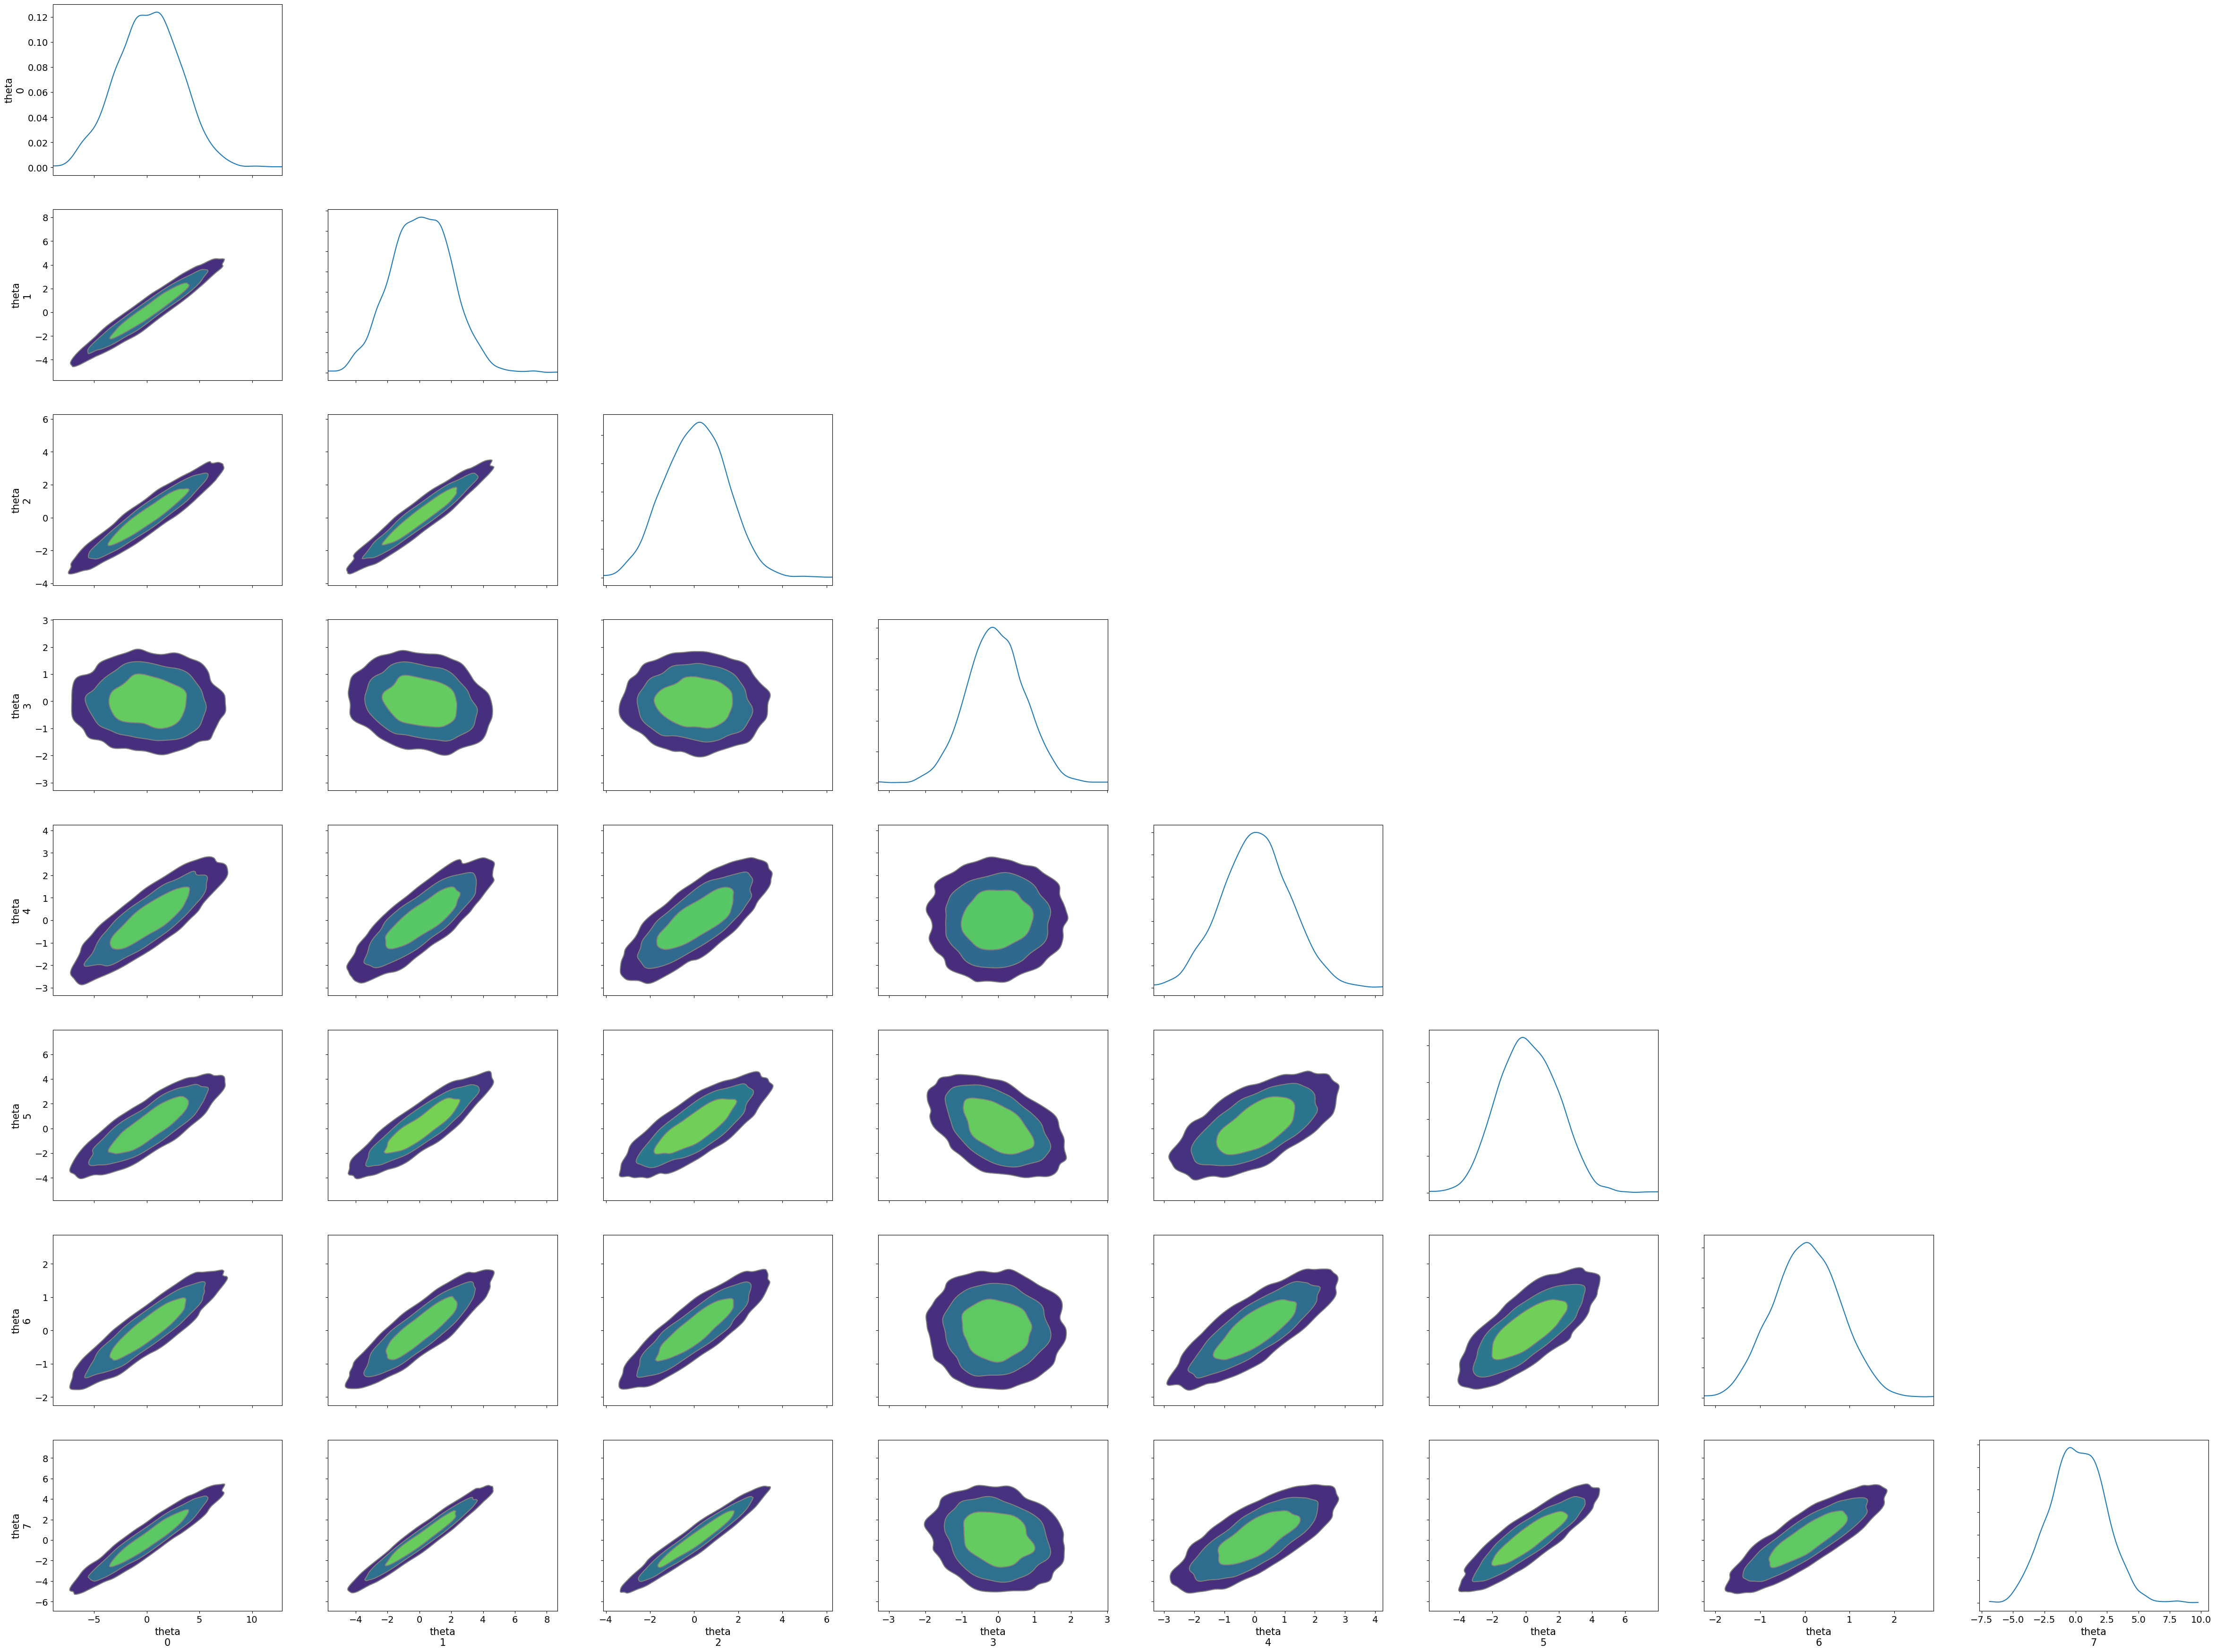

In [4]:
az.plot_pair(idata, var_names=["theta"], kind="kde", marginals=True)

I got these warnings:

Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.

Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.

Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.

Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details

In order to replicate the paper, I can increase the tree depth. If, instead, I just want a better sampling, I can increase the target acceptance rate.

In [5]:
with pm.Model() as model:
    theta_p = pm.MvNormal("theta_p", mu=np.zeros(D), tau=A, shape=D)  # tau = precision

    idata_p = pm.sample(
        draws = N,
        tune = warmup,
        chains = 4,
        target_accept = delta,
        random_seed = 2026,
        progressbar = True,
        nuts_sampler = "pymc",
        max_treedepth = 14
    )

theta_draws_p = idata_p.posterior["theta_p"].values  # shape (chains, draws, D)
theta_flat_p = theta_draws_p.reshape(-1, D)

q_p = np.einsum("ni,ij,nj->n", theta_flat_p, A, theta_flat_p)

print("mean q (theory D):", q_p.mean(), f"({D})")
print("var  q (theory 2D):", q_p.var(), f"({2*D})")

mean_emp_p = theta_flat_p.mean(axis=0)
print("mean abs avg:", np.abs(mean_emp_p).mean())

cov_emp_p = np.cov(theta_flat_p, rowvar=False, bias=True)
rel_err_p = np.linalg.norm(cov_emp_p - cov_theory, 'fro') / np.linalg.norm(cov_theory, 'fro')
print("rel cov error:", rel_err_p)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [theta_p]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 292 seconds.


mean q (theory D): 250.02412100392476 (250)
var  q (theory 2D): 479.85678082084155 (500)
mean abs avg: 0.04295334211086581
rel cov error: 0.07714209053335884


Instead, for better performance

In [6]:
with pm.Model() as model:
    theta_perf = pm.MvNormal("theta_perf", mu=np.zeros(D), tau=A, shape=D)  # tau = precision

    idata_perf = pm.sample(
        draws = N,
        tune = warmup,
        chains = 4,
        target_accept = 0.90,
        random_seed = 2026,
        progressbar = True,
        nuts_sampler = "pymc",
        #init="adapt_full",
        max_treedepth = 14
    )

theta_perf = idata_perf.posterior["theta_perf"].values  # shape (chains, draws, D)
theta_perf = theta_perf.reshape(-1, D)

q_perf = np.einsum("ni,ij,nj->n", theta_perf, A, theta_perf)

print("mean q (theory D):", q_perf.mean(), f"({D})")
print("var  q (theory 2D):", q_perf.var(), f"({2*D})")

mean_perf = theta_perf.mean(axis=0)
print("mean abs avg:", np.abs(mean_perf).mean())

cov_perf = np.cov(theta_perf, rowvar=False, bias=True)
rel_perf = np.linalg.norm(cov_perf - cov_theory, 'fro') / np.linalg.norm(cov_theory, 'fro')
print("rel cov error:", rel_perf)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [theta_perf]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 501 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


mean q (theory D): 249.95791998832365 (250)
var  q (theory 2D): 529.5133768890719 (500)
mean abs avg: 0.06500861102293454
rel cov error: 0.07474392033568605


/home/mattia/anaconda3/envs/alice/lib/python3.13/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='theta_perf\n0'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta_perf\n1'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta_perf\n2'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta_perf\n3'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta_perf\n4'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta_perf\n5'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta_perf\n6'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='theta_perf\n0', ylabel='theta_perf\n7'>,
        <Axes: xlabel='theta_perf\n1'>, <Axes: xlabel='theta_perf\n2'>,
        <Axes: xlabel='theta_pe

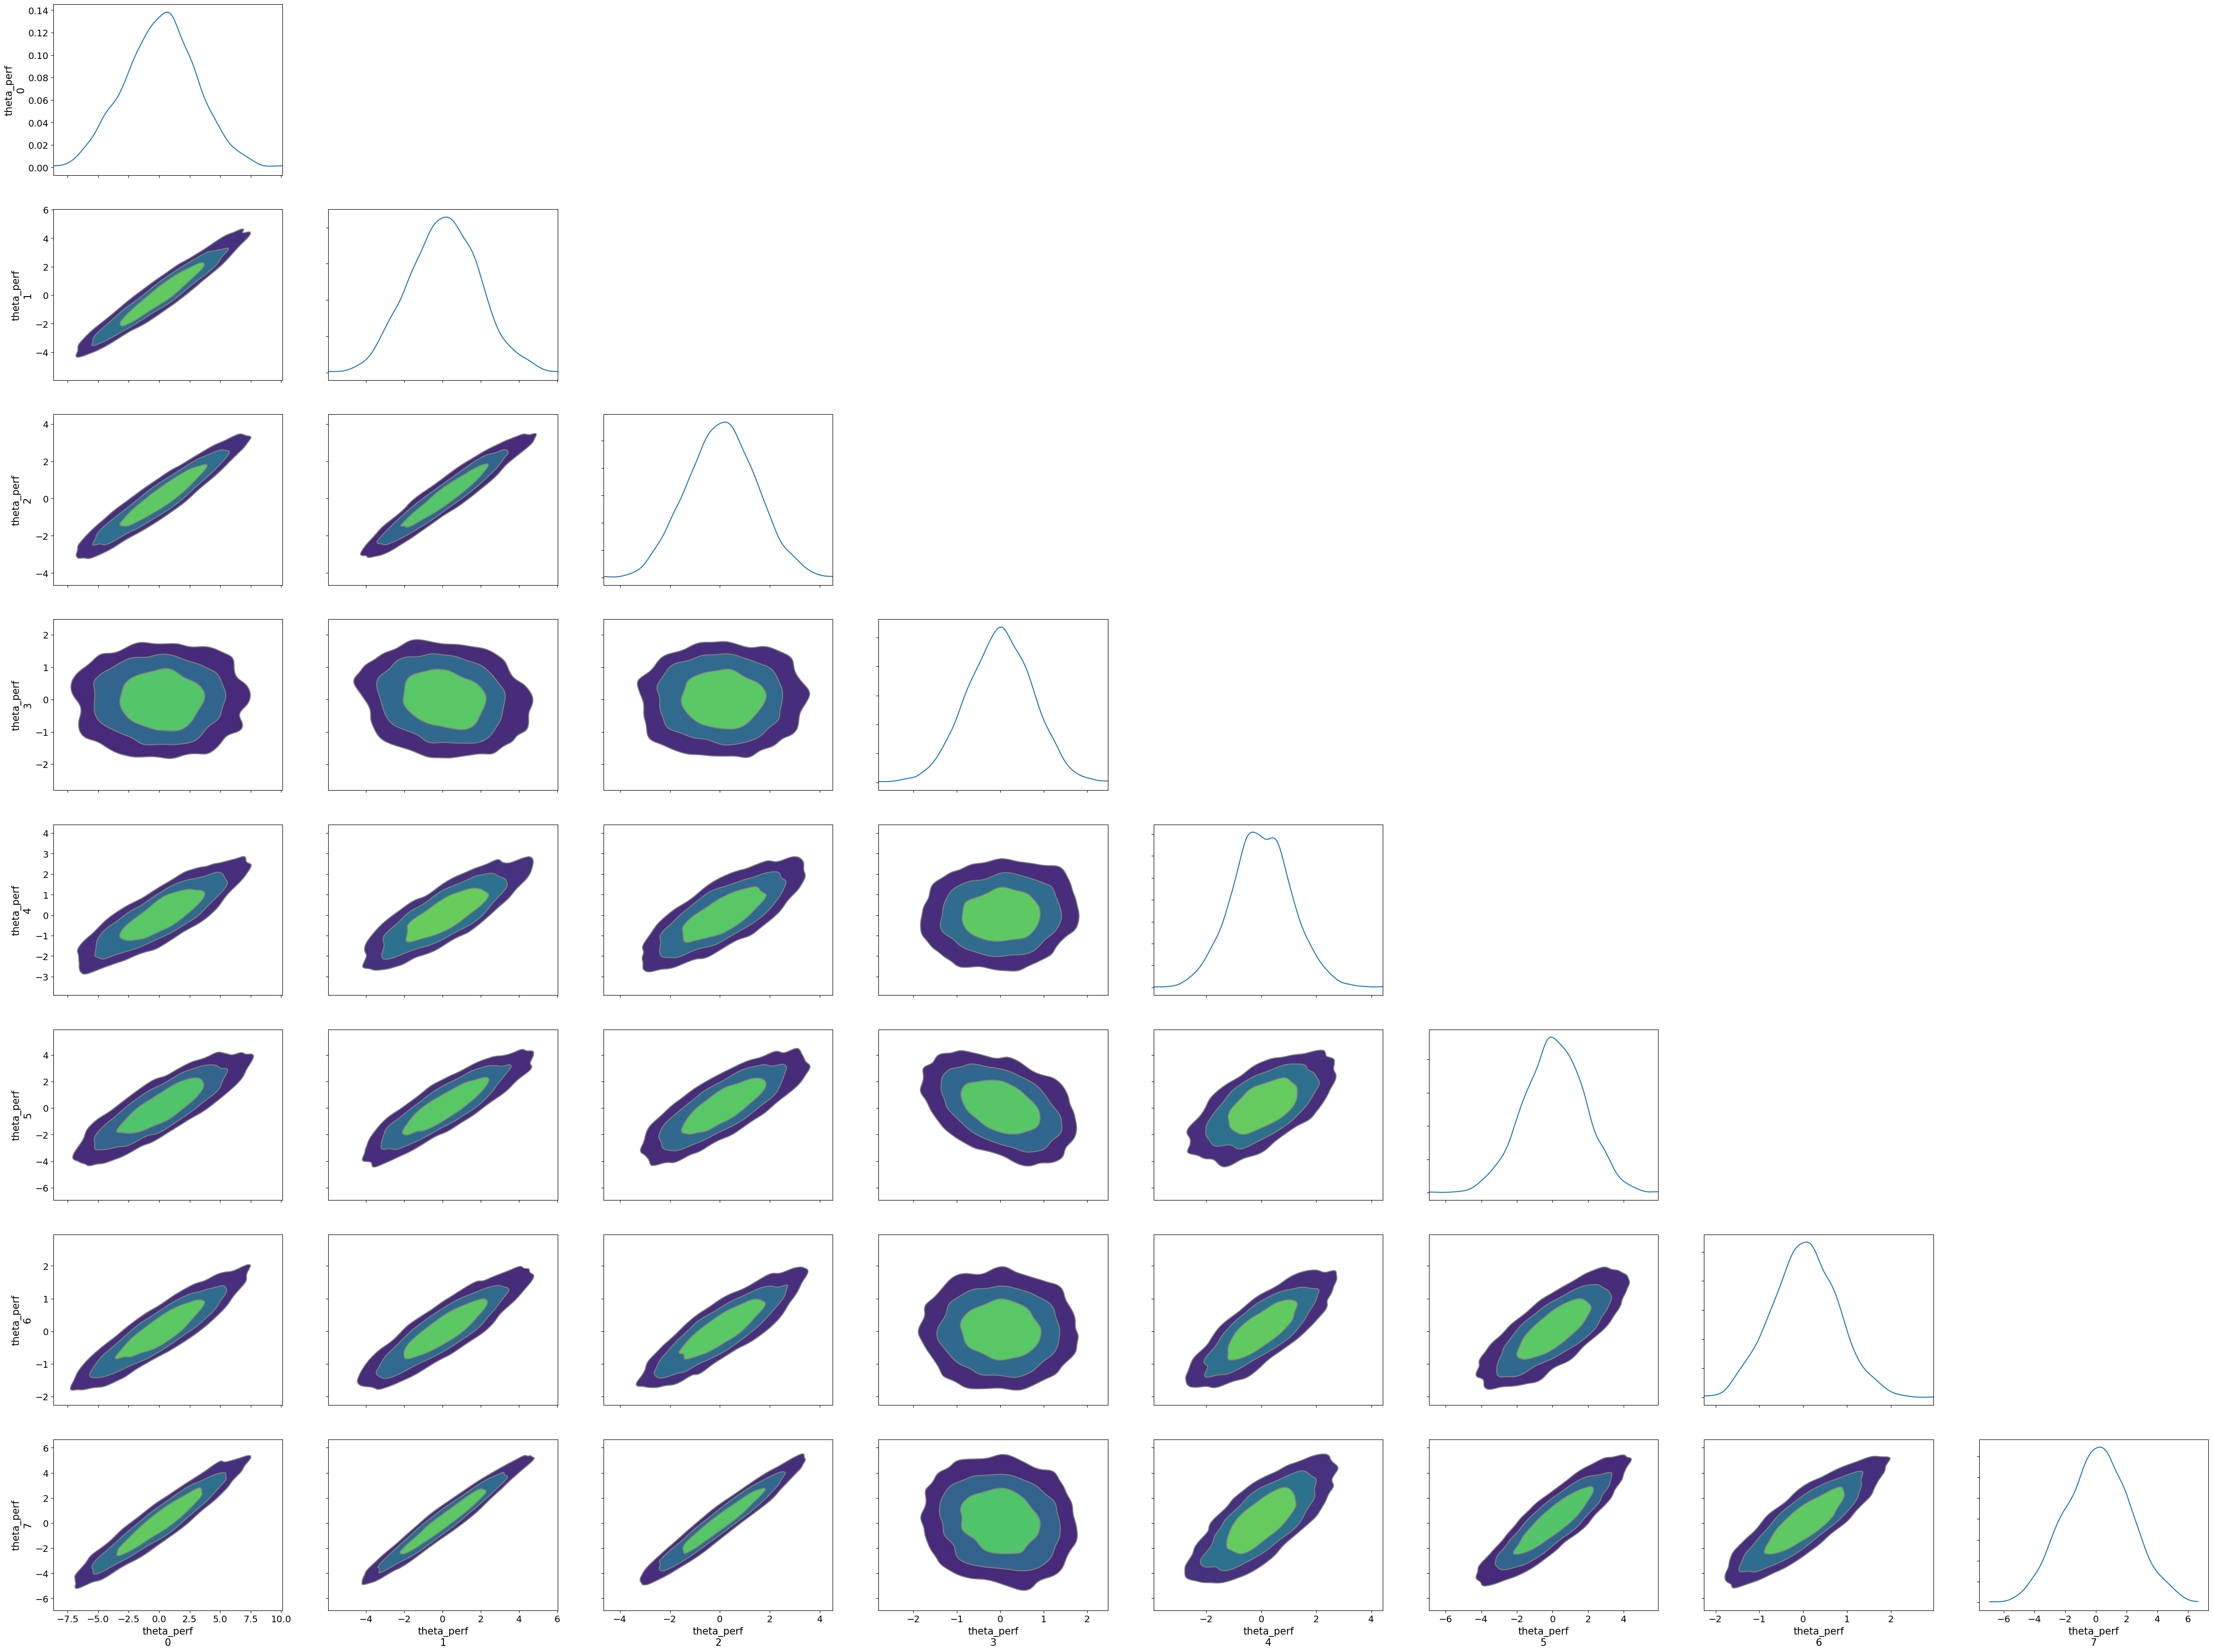

In [7]:
az.plot_pair(idata_perf, var_names=["theta_perf"], kind="kde", marginals=True)

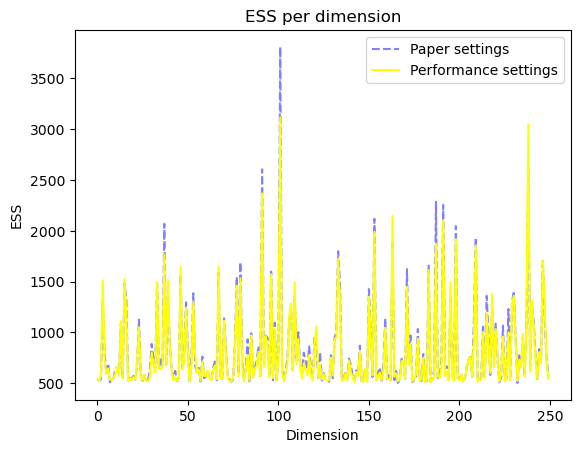

In [10]:
ess_nuts_paper = az.summary(idata_p, var_names=["theta_p"])["ess_bulk"].values
ess_nuts_perf  = az.summary(idata_perf,  var_names=["theta_perf"])["ess_bulk"].values

import matplotlib.pyplot as plt

plt.plot(ess_nuts_paper, label="Paper settings", ls="dashed", alpha = 0.5, color="blue")
plt.plot(ess_nuts_perf, label="Performance settings", color="yellow")
plt.xlabel("Dimension")
plt.ylabel("ESS")
plt.legend()
plt.title("ESS per dimension");

In [13]:
mu_true = np.zeros(D)
print("--------------------Paper Settings--------------------\n")
display(az.summary(idata_p))
hdi_p = az.hdi(idata_p, var_names=["theta_p"], hdi_prob=0.95)["theta_p"].values
covered_p = (mu_true >= hdi_p[:, 0]) & (mu_true <= hdi_p[:, 1])
print("\nCoverage count:", covered_p.sum(), "/", D)
print("\n--------------------Performance Settings--------------------\n")
display(az.summary(idata_perf))
hdi_perf = az.hdi(idata_perf, var_names=["theta_perf"], hdi_prob=0.95)["theta_perf"].values
covered_perf = (mu_true >= hdi_perf[:, 0]) & (mu_true <= hdi_perf[:, 1])
print("\nCoverage count:", covered_perf.sum(), "/", D)

--------------------Paper Settings--------------------



,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_p[0],-0.072,2.914,-5.846,5.263,0.126,0.074,534.0,921.0,1.01
theta_p[1],-0.053,1.813,-3.517,3.320,0.079,0.046,527.0,965.0,1.01
theta_p[2],-0.022,1.360,-2.686,2.426,0.058,0.033,539.0,986.0,1.01
theta_p[3],0.034,0.784,-1.411,1.516,0.022,0.015,1294.0,1717.0,1.00
theta_p[4],-0.025,1.093,-2.060,2.014,0.038,0.022,807.0,1473.0,1.00
...,...,...,...,...,...,...,...,...,...
theta_p[245],0.004,1.232,-2.377,2.261,0.046,0.028,721.0,1269.0,1.01
theta_p[246],-0.016,0.579,-1.081,1.065,0.014,0.011,1705.0,1816.0,1.00
theta_p[247],0.067,1.198,-2.152,2.331,0.035,0.024,1166.0,1479.0,1.00
theta_p[248],0.006,0.990,-1.700,2.036,0.036,0.022,752.0,1373.0,1.00



Coverage count: 250 / 250

--------------------Performance Settings--------------------



,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_perf[0],0.128,2.925,-5.846,5.169,0.126,0.072,540.0,935.0,1.01
theta_perf[1],0.080,1.814,-3.436,3.415,0.079,0.044,526.0,799.0,1.01
theta_perf[2],0.076,1.370,-2.452,2.728,0.058,0.031,565.0,905.0,1.01
theta_perf[3],-0.012,0.754,-1.371,1.426,0.019,0.013,1509.0,2060.0,1.00
theta_perf[4],0.016,1.094,-2.134,2.010,0.040,0.022,736.0,1300.0,1.00
...,...,...,...,...,...,...,...,...,...
theta_perf[245],-0.027,1.242,-2.320,2.400,0.047,0.028,696.0,1243.0,1.01
theta_perf[246],0.016,0.566,-1.060,1.041,0.014,0.010,1705.0,2113.0,1.00
theta_perf[247],-0.011,1.137,-2.170,2.085,0.031,0.021,1301.0,1645.0,1.00
theta_perf[248],0.035,0.992,-1.816,1.906,0.037,0.021,726.0,1311.0,1.00



Coverage count: 250 / 250
